<a href="https://colab.research.google.com/github/Aaryan8597/AI-ML-AaryanLamichhane2408597-/blob/main/Tutorial7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Necessary Imports
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from PIL import Image
from sklearn.model_selection import train_test_split

# Step 1: Load, pre - process and add a Noise to the Dataset:

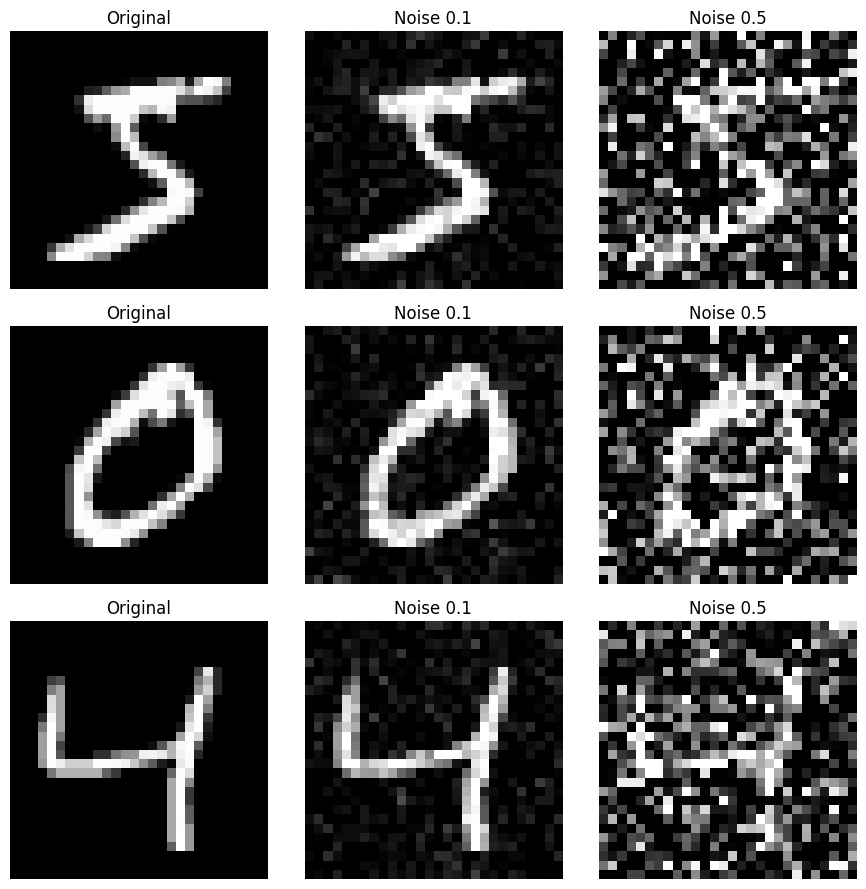

In [3]:
# loading and preprocessing the MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# generating noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc = 0.0, scale = 1.0, size = x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc = 0.0, scale = 1.0, size = x_test.shape)

#clipping th epixel values to 0,1
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

#visualizing
n = 3
plt.figure(figsize=(9,9))
for i in range(n):
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap = 'gray')
    plt.title("Original")
    plt.axis('off')

    #for low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap = 'gray')
    plt.title("Noise 0.1")
    plt.axis("off")
    #for high noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap = 'gray')
    plt.title("Noise 0.5")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Building the convolutional Denoising Autoencoder Model

## Encoder

In [10]:
def build_encoder(input_shape = (28,28,1)):
  input_img = Input(shape=input_shape, name = "input")
  x = Conv2D(32, (3,3), activation = 'relu', padding = 'same')(input_img)
  x = MaxPooling2D((2,2), padding = 'same')(x)
  x = Conv2D(64, (3,3), activation = 'relu', padding = 'same')(x)
  encoded = MaxPooling2D(2,2, padding = 'same', name = "encoded")(x)
  return input_img, encoded

## Decoder

In [11]:
def build_decoder(encoded_input):
  x = Conv2D(64, (3,3), activation = 'relu', padding = 'same')(encoded_input)
  x = UpSampling2D((2,2))(x)
  x = Conv2D(32, (3,3), activation = 'relu', padding = 'same')(x)
  x = UpSampling2D((2,2))(x)
  decoded = Conv2D(1, (3,3), activation = 'sigmoid', padding = 'same', name = "decoded")(x)
  return decoded

## Autoencoder

In [14]:
def build_autoencoder():
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs = input_img, outputs = decoded_output, name = "autoencoder")
  autoencoder.compile(optimizer = 'adam', loss = 'binary_crossentropy')
  return autoencoder

## COmpiling the model

In [15]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# Training the Autoencoder

In [16]:
autoencoder = build_autoencoder()
#reaining with noisy input and clean target
history = autoencoder.fit(x_train_noisy_high, x_train, epochs = 10, batch_size = 128, shuffle = True,
                        validation_data = (x_test_noisy_high, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 174s 366ms/step - loss: 0.1611 - val_loss: 0.1164
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 164s 350ms/step - loss: 0.1115 - val_loss: 0.1067
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 348ms/step - loss: 0.1062 - val_loss: 0.1035
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 389ms/step - loss: 0.1033 - val_loss: 0.1011
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 217s 420ms/step - loss: 0.1014 - val_loss: 0.0997
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 173s 358ms/step - loss: 0.1000 - val_loss: 0.0988
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 167s 356ms/step - loss: 0.0990 - val_loss: 0.0978
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 167s 356ms/step - loss: 0.0982 - val_loss: 0.0972
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 348ms/step - loss: 0.0976 - val_loss: 0.0968
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 162s 346ms/step - loss: 0.0970 - val_loss: 0.0962


# Evaluating the autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step


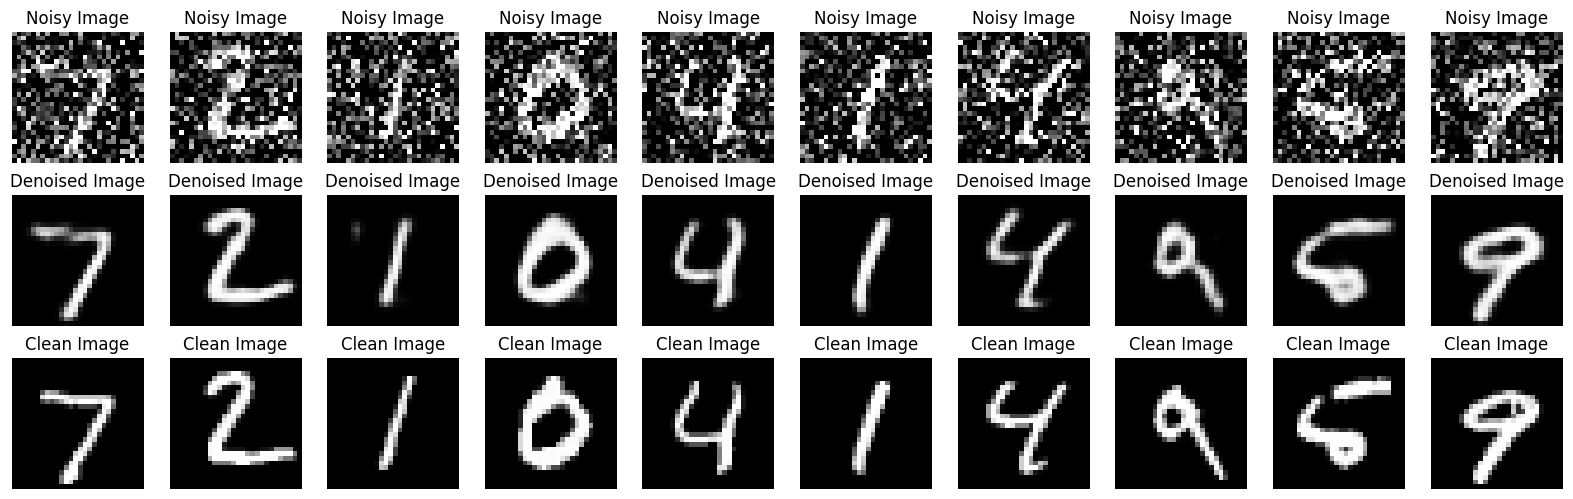

In [18]:
x_test_noisy = x_test_noisy_high
clean_images = x_test
denoised_images = autoencoder.predict(x_test_noisy)
#function for displating images
def plot_images(noisy_images, denoised_images, clean_images, n = 10):
  plt.figure(figsize = (20,6))
  for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28,28), cmap = 'gray')
    plt.title("Noisy Image")
    plt.axis('off')

    # for denoised images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28,28), cmap = 'gray')
    plt.title("Denoised Image")
    plt.axis('off')

    #for clean images
    plt.subplot(3,n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28,28), cmap = 'gray')
    plt.title("Clean Image")
    plt.axis('off')
  plt.show()

# displaying the first 10 images
plot_images(x_test_noisy, denoised_images, x_test, n = 10)

# Exercise BUilding a benoising Convolutional Autoencoder

## Dataset Preparation and Preprocessing

In [3]:
train_path = '/content/drive/MyDrive/AIML/Data/DevanagariHandwrittenDigitDataset/Train'
test_path = '/content/drive/MyDrive/AIML/Data/DevanagariHandwrittenDigitDataset/Test'
img_size = (28,28)
train_images = []

# loading the training data
train_images = []
for folder in sorted(os.listdir(train_path)):
    folder_path = os.path.join(train_path, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            img = Image.open(os.path.join(folder_path, file)).convert('L')
            img = img.resize(img_size)
            train_images.append(np.asarray(img) / 255.0)
x_train = np.array(train_images)
x_train = np.expand_dims(x_train, axis=-1)

#loading the test data
test_images = []
for folder in sorted(os.listdir(test_path)):
    folder_path = os.path.join(test_path, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            img = Image.open(os.path.join(folder_path, file)).convert('L')
            img = img.resize(img_size)
            test_images.append(np.asarray(img) / 255.0)

x_test = np.array(test_images)
x_test = np.expand_dims(x_test, axis=-1)

# adding noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# keeping the value in 0,1 range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print(f"Loaded {len(x_train)} training images.")
print(f"Loaded {len(x_test)} test images.")

# Spliting the training data to create a validation set
x_train, x_val, x_train_noisy, x_val_noisy = train_test_split(x_train, x_train_noisy, test_size=0.2, random_state=42)

print(f"Final Training images: {len(x_train)}")
print(f"Validation images: {len(x_val)}")


Loaded 17000 training images.
Loaded 3000 test images.
Final Training images: 13600
Validation images: 3400


## Building the denoising COnvolutional Autoencoder

In [7]:
def build_encoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape, name="encoder_input")
    # Layer 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # Layer 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # Layer 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # Layer 4
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)

    return input_img, encoded

In [8]:
# building decoder
def build_decoder(encoded_input):
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    decoded = Cropping2D(cropping=((2, 2), (2, 2)), name="decoder")(decoded)
    return decoded

## completing and COmpiling the Autoencoder

In [9]:
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Cropping2D)            │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627,969 (2.40 MB)

 Trainable params: 627,969 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

## Training the Denoising Autoencoder

In [10]:
autoencoder = build_autoencoder()
history = autoencoder.fit(x_train_noisy, x_train, epochs=10, batch_size=128, shuffle=True,
                          validation_data=(x_test_noisy, x_test))

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 101s 892ms/step - loss: 0.4756 - val_loss: 0.4463
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 101s 948ms/step - loss: 0.3629 - val_loss: 0.3064
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 128s 818ms/step - loss: 0.2824 - val_loss: 0.2639
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 89s 831ms/step - loss: 0.2507 - val_loss: 0.2408
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 141s 828ms/step - loss: 0.2336 - val_loss: 0.2355
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 89s 833ms/step - loss: 0.2231 - val_loss: 0.2207
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 141s 828ms/step - loss: 0.2154 - val_loss: 0.2148
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 142s 828ms/step - loss: 0.2098 - val_loss: 0.2110
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 87s 813ms/step - loss: 0.2065 - val_loss: 0.2074
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 89s 830ms/step - loss: 0.2023 - val_loss: 0.2033


# Evaluating and VIsualizing the result

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step


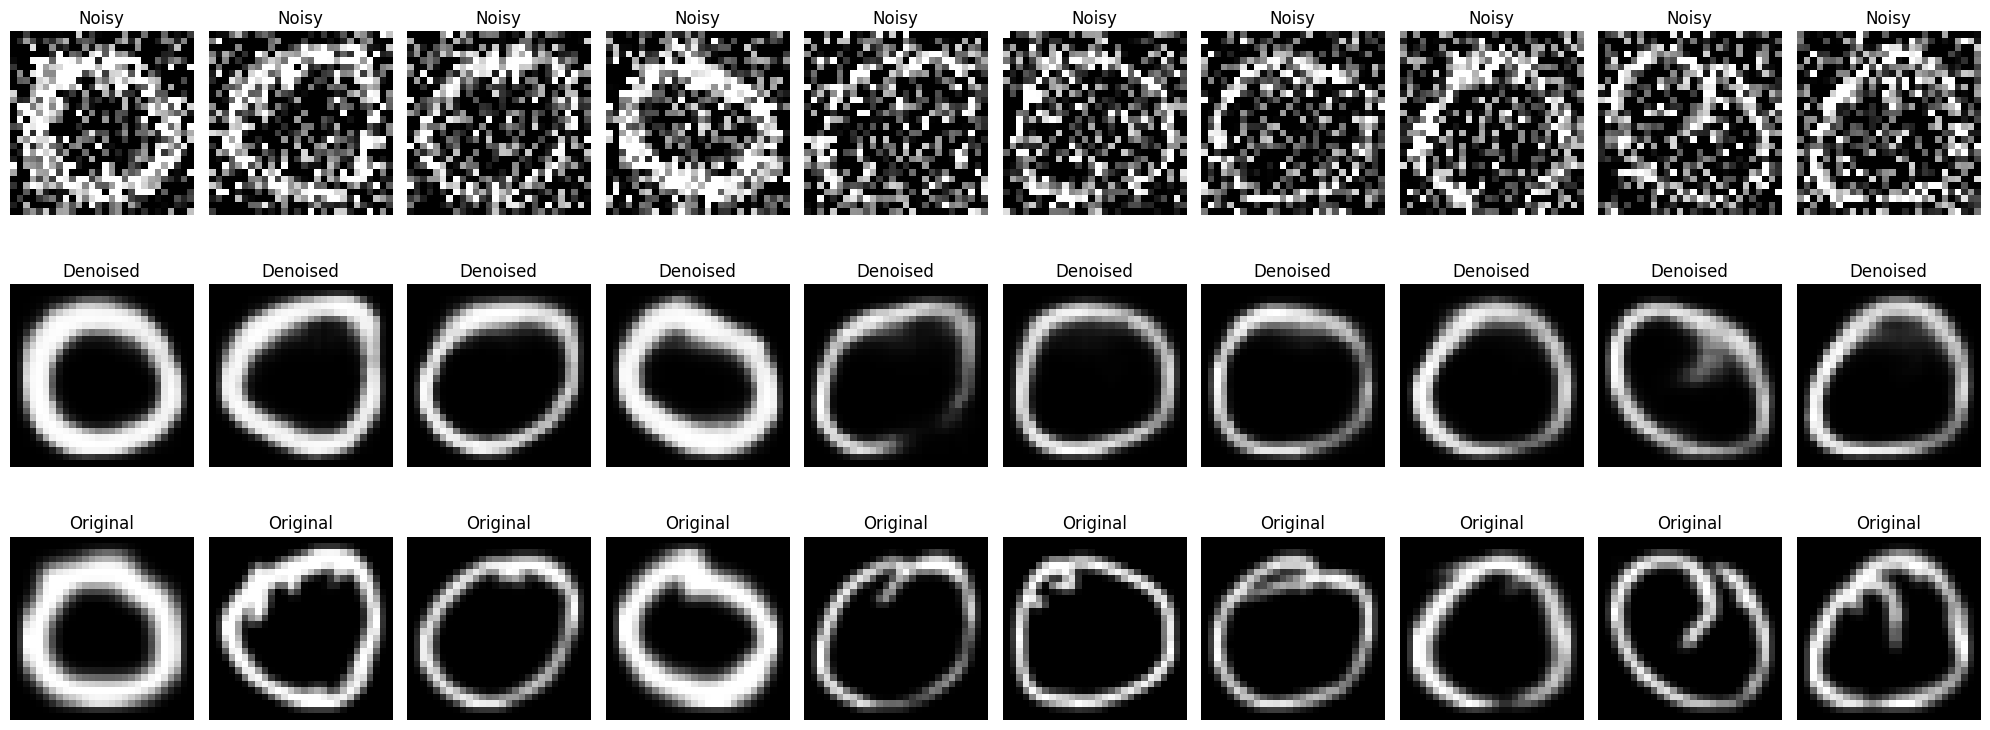

In [11]:
import matplotlib.pyplot as plt
denoised_images = autoencoder.predict(x_test_noisy)

def plot_devnagari_results(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 8))
    for i in range(n):
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        ax = plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
plot_devnagari_results(x_test_noisy, denoised_images, x_test, n=10)